170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset CIFAR-10 caricato e normalizzato.
Dimensioni delle immagini di training: (50000, 32, 32, 3)
Dimensioni delle etichette di training: (50000, 1)
Dimensioni delle immagini di test: (10000, 32, 32, 3)
Dimensioni delle etichette di test: (10000, 1)


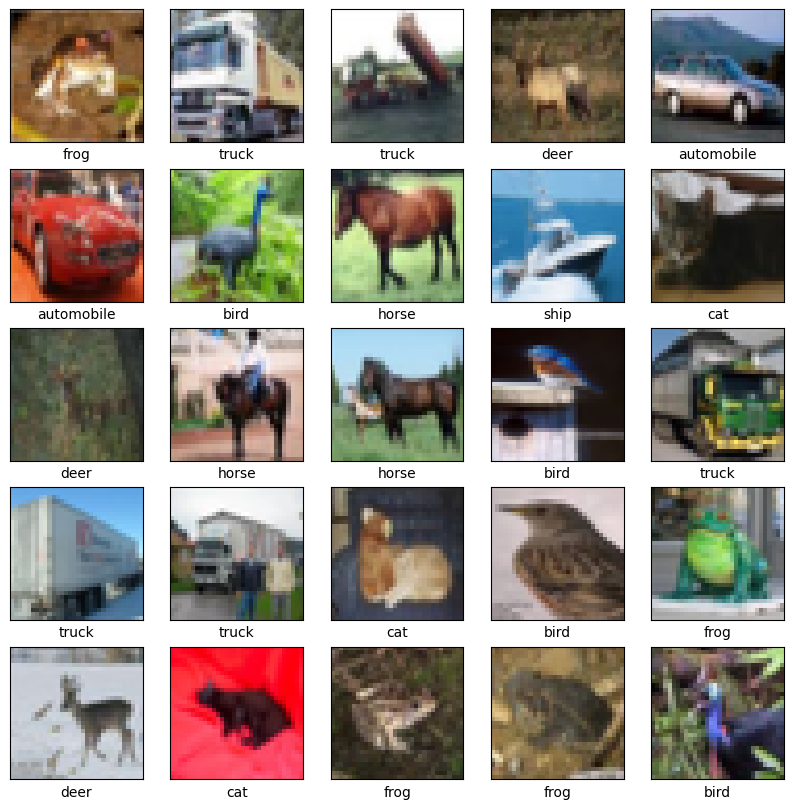

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Caricamento del dataset CIFAR-10
# Il dataset CIFAR-10 contiene 10 classi diverse, inclusi veicoli e animali.
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalizzazione dei valori dei pixel a un intervallo tra 0 e 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Definizione dei nomi delle classi per CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Dataset CIFAR-10 caricato e normalizzato.")
print(f"Dimensioni delle immagini di training: {train_images.shape}")
print(f"Dimensioni delle etichette di training: {train_labels.shape}")
print(f"Dimensioni delle immagini di test: {test_images.shape}")
print(f"Dimensioni delle etichette di test: {test_labels.shape}")

# È possibile visualizzare alcune immagini per verifica
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

# EDA
Dato lo scopo del progetto che riguarda la guida autonoma per veicoli, penso sia giusto semplificare il dataset andando a levare dal conto tutte le identificazioni meno fastidiose/improbabili.
- airplane
- bird
- frog
- horse
- ship

In [3]:
import numpy as np

# Re-initialize class_names to its original state for robust filtering
original_cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_names = original_cifar10_class_names

# Classi da rimuovere
classes_to_remove = ['airplane', 'bird', 'frog', 'horse', 'ship']

# Ottieni gli indici delle classi da rimuovere
remove_indices = [class_names.index(cls) for cls in classes_to_remove]

# Crea una maschera booleana per le classi da mantenere
# Per le immagini di training
keep_train_mask = np.isin(train_labels.flatten(), remove_indices, invert=True)
filtered_train_images = train_images[keep_train_mask]
filtered_train_labels = train_labels[keep_train_mask]

# Per le immagini di test
keep_test_mask = np.isin(test_labels.flatten(), remove_indices, invert=True)
filtered_test_images = test_images[keep_test_mask]
filtered_test_labels = test_labels[keep_test_mask]

# Aggiorna i nomi delle classi per riflettere solo quelle mantenute
remaining_class_names = [cls for i, cls in enumerate(class_names) if i not in remove_indices]

# Creare una mappatura dai vecchi indici delle classi ai nuovi indici sequenziali (0, 1, 2, ...)
# Prima, ottenere gli indici originali delle classi mantenute
original_kept_indices = [i for i, cls in enumerate(original_cifar10_class_names) if i not in remove_indices]

# Creare un dizionario di mappatura
old_to_new_label_map = {old_idx: new_idx for new_idx, old_idx in enumerate(original_kept_indices)}

# Applicare la mappatura alle etichette di training e test
# Converti le etichette in un formato 1D per facilitare la mappatura
filtered_train_labels_flat = filtered_train_labels.flatten()
filtered_test_labels_flat = filtered_test_labels.flatten()

# Applica la mappatura usando una funzione vettorizzata per efficienza
map_func = np.vectorize(lambda x: old_to_new_label_map[x])
new_train_labels = map_func(filtered_train_labels_flat).reshape(-1, 1)
new_test_labels = map_func(filtered_test_labels_flat).reshape(-1, 1)


# Aggiorna le variabili globali
train_images = filtered_train_images
train_labels = new_train_labels
test_images = filtered_test_images
test_labels = new_test_labels
class_names = remaining_class_names

print("Dataset CIFAR-10 filtrato e etichette rimappate.")
print(f"Nuove dimensioni delle immagini di training: {train_images.shape}")
print(f"Nuove dimensioni delle etichette di training: {train_labels.shape}")
print(f"Nuove dimensioni delle immagini di test: {test_images.shape}")
print(f"Nuove dimensioni delle etichette di test: {test_labels.shape}")
print(f"Classi rimanenti: {class_names}")

Dataset CIFAR-10 filtrato e etichette rimappate.
Nuove dimensioni delle immagini di training: (25000, 32, 32, 3)
Nuove dimensioni delle etichette di training: (25000, 1)
Nuove dimensioni delle immagini di test: (5000, 32, 32, 3)
Nuove dimensioni delle etichette di test: (5000, 1)
Classi rimanenti: ['automobile', 'cat', 'deer', 'dog', 'truck']


# Adesso voglio andare a vedere quanti data points ho per classe, mi interessa vedere quanto il dataset è bilanciato
Il dataset si presenta molto bilanciato, non mi aspetto particolari problemi anche con una CNN normale. Nelle metriche, non serve inserire una macro-F1 possono bastare le metriche classiche.

In [4]:
# Usa np.bincount per contare le occorrenze di ogni etichetta
train_counts = np.bincount(train_labels.flatten())
for i, count in enumerate(train_counts):
    print(f"  {class_names[i]}: {count}")

print("\nConteggio dei data points per classe nel test set:")
test_counts = np.bincount(test_labels.flatten())
for i, count in enumerate(test_counts):
    print(f"  {class_names[i]}: {count}")

# È possibile aggiungere un controllo per vedere se il dataset è bilanciato
# Un dataset è bilanciato se il numero di campioni per classe è approssimativamente lo stesso.

# Per esempio, puoi calcolare la deviazione standard o il rapporto min/max
max_train_count = np.max(train_counts)
min_train_count = np.min(train_counts)

max_test_count = np.max(test_counts)
min_test_count = np.min(test_counts)


  automobile: 5000
  cat: 5000
  deer: 5000
  dog: 5000
  truck: 5000

Conteggio dei data points per classe nel test set:
  automobile: 1000
  cat: 1000
  deer: 1000
  dog: 1000
  truck: 1000


# Costruzione di una mia architettura convoluzionale da allenare

In [8]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(len(class_names), activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,245 (477.52 KB)

 Trainable params: 122,245 (477.52 KB)

 Non-trainable params: 0 (0.00 B)

# Allenamento e Test di questa architettura molto leggera

In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.5163 - loss: 1.0903 - val_accuracy: 0.6208 - val_loss: 0.9079
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.6406 - loss: 0.8512 - val_accuracy: 0.6514 - val_loss: 0.8199
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.6858 - loss: 0.7644 - val_accuracy: 0.6894 - val_loss: 0.7723
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7158 - loss: 0.6952 - val_accuracy: 0.7102 - val_loss: 0.7139
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.7455 - loss: 0.6326 - val_accuracy: 0.7268 - val_loss: 0.6850
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.7606 - loss: 0.5879 - val_accuracy: 0.7348 - val_loss: 0.6674
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.7839 - loss: 0.5403 - val_accuracy: 0.7484 - val_loss: 0.6364
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.7977 - loss: 0.5041 - 

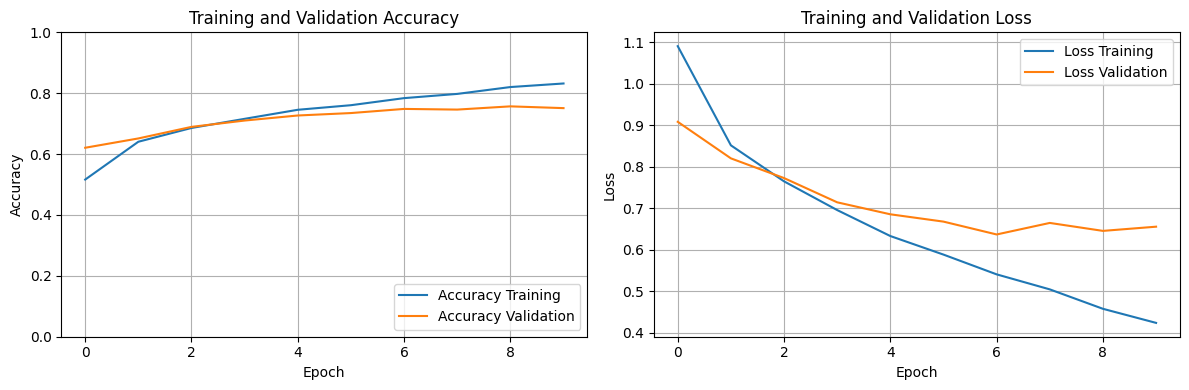

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy Training')
plt.plot(history.history['val_accuracy'], label='Accuracy Validation')
plt.xlabel('Epoch')
plt.grid(True)
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

# Dall'andamento delle curve capisco che il modello sta iniziando a overfittare

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step

Classification Report:
              precision    recall  f1-score   support

  automobile       0.90      0.82      0.86      1000
         cat       0.65      0.60      0.62      1000
        deer       0.82      0.79      0.80      1000
         dog       0.68      0.72      0.70      1000
       truck       0.79      0.89      0.83      1000

    accuracy                           0.76      5000
   macro avg       0.77      0.76      0.76      5000
weighted avg       0.77      0.76      0.76      5000



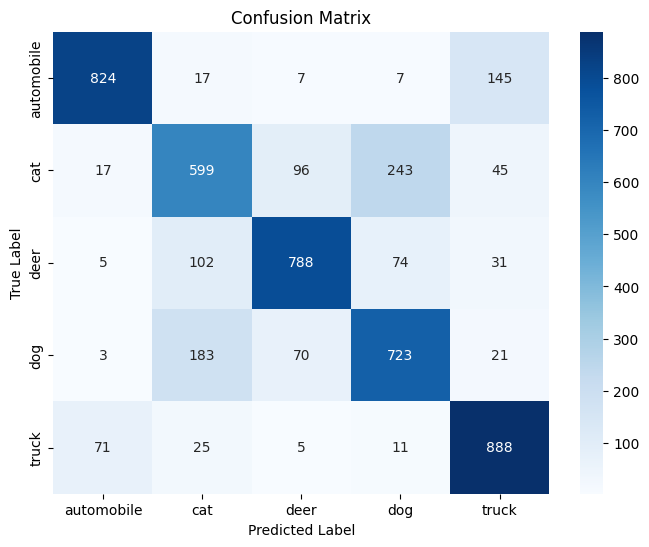

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Previsioni sul set di test
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Le etichette vere sono già filtrate e rimappate (0, 1, 2, 3, 4)
true_labels_flat = test_labels.flatten()

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(true_labels_flat, predicted_labels, target_names=class_names))

# --- Confusion Matrix ---
conf_matrix = confusion_matrix(true_labels_flat, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Dalla matrice di confusione comprendiamo un risultato abbastanza chiaro, riusciamo a classificare molto bene truck e automobili, anche se a volte si fa confusione tra i due (vedendo riga 1 ultima colonna o ultima riga prima colonna). Per gli animali invece la rete fa un po' più di confusione (anche se riesce a distinguere abbastanza bene tra animale e veicolo)

### Architettura ResNet-18 Personalizzata

ResNet-18 è caratterizzata da blocchi residui che permettono alla rete di apprendere funzioni identità, facilitando l'allenamento di modelli molto profondi. Ogni blocco residuo aggiunge l'input del blocco stesso all'output del blocco, dopo una serie di strati convoluzionali e di normalizzazione batch.

La struttura che replicheremo include:
1.  **Strato Convoluzionale Iniziale:** Un `Conv2D` con filtro 7x7, seguito da `BatchNormalization`, `ReLU` e `MaxPooling` per l'estrazione delle feature iniziali e il downsampling.
2.  **Stadi Residui:** Quattro stadi, ciascuno contenente due blocchi residui. I primi blocchi di ogni stadio (tranne il primo) utilizzano uno `stride=2` per il downsampling e una convoluzione scorciatoia (`conv_shortcut=True`) per far combaciare le dimensioni tra l'input del blocco e l'output della strada principale.
3.  **Classificatore:** Un `GlobalAveragePooling2D` per ridurre le dimensioni spaziali, seguito da un `Dense` layer con attivazione `softmax` per la classificazione finale.

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def resnet_block(x, filters, kernel_size=3, stride=1, conv_shortcut=False, name=None):
    """Definisce un blocco residuo base (usato in ResNet-18/34)."""
    if name is None:
        name = str(tf.keras.backend.get_uid('res_block'))

    # Strada principale del blocco
    y = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                      kernel_initializer='he_normal', name=name + '_conv1')(x)
    y = layers.BatchNormalization(name=name + '_bn1')(y)
    y = layers.Activation('relu', name=name + '_relu1')(y)

    y = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal', name=name + '_conv2')(y)
    y = layers.BatchNormalization(name=name + '_bn2')(y)

    # Scorciatoia
    if conv_shortcut:
        # Se le dimensioni cambiano, usiamo una convoluzione 1x1 per far combaciare la scorciatoia
        shortcut = layers.Conv2D(filters, 1, strides=stride,
                                 kernel_initializer='he_normal', name=name + '_shortcut_conv')(x)
        shortcut = layers.BatchNormalization(name=name + '_shortcut_bn')(shortcut)
    else:
        # Altrimenti, la scorciatoia è l'input stesso
        shortcut = x

    # Somma la scorciatoia all'output della strada principale e applica ReLU
    y = layers.Add(name=name + '_add')([shortcut, y])
    y = layers.Activation('relu', name=name + '_relu_out')(y)
    return y

def create_resnet18(input_shape, num_classes):
    """Costruisce un modello ResNet-18."""
    inputs = layers.Input(shape=input_shape)

    # Conv1
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                      kernel_initializer='he_normal', name='conv1_conv')(inputs)
    x = layers.BatchNormalization(name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name='pool1')(x)

    # Stage 2 (64 filters)
    x = resnet_block(x, 64, conv_shortcut=False, name='res2a')
    x = resnet_block(x, 64, conv_shortcut=False, name='res2b')

    # Stage 3 (128 filters)
    x = resnet_block(x, 128, stride=2, conv_shortcut=True, name='res3a') # Downsample e scorciatoia con conv
    x = resnet_block(x, 128, conv_shortcut=False, name='res3b')

    # Stage 4 (256 filters)
    x = resnet_block(x, 256, stride=2, conv_shortcut=True, name='res4a') # Downsample e scorciatoia con conv
    x = resnet_block(x, 256, conv_shortcut=False, name='res4b')

    # Stage 5 (512 filters)
    x = resnet_block(x, 512, stride=2, conv_shortcut=True, name='res5a') # Downsample e scorciatoia con conv
    x = resnet_block(x, 512, conv_shortcut=False, name='res5b')

    # Classificatore
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='resnet18')
    return model

# Esempio di utilizzo con i dati CIFAR-10 filtrati
input_shape = train_images.shape[1:]  # (32, 32, 3)
num_classes = len(class_names)       # 5 classi dopo il filtro

resnet18_model = create_resnet18(input_shape, num_classes)
resnet18_model.summary()

Model: "resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 8, 8, 64)  │          0 │ conv1_relu[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_conv1         │ (None, 8, 8, 64)  │     36,928 │ pool1[0][0]       │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_bn1           │ (None, 8, 8, 64)  │        256 │ res2a_conv1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_relu1         │ (None, 8, 8, 64)  │          0 │ res2a_bn1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_conv2         │ (None, 8, 8, 64)  │     36,928 │ res2a_relu1[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_bn2           │ (None, 8, 8, 64)  │        256 │ res2a_conv2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_add (Add)     │ (None, 8, 8, 64)  │          0 │ pool1[0][0],      │
│                     │                   │            │ res2a_bn2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_relu_out      │ (None, 8, 8, 64)  │          0 │ res2a_add[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_conv1         │ (None, 8, 8, 64)  │     36,928 │ res2a_relu_out[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_bn1           │ (None, 8, 8, 64)  │        256 │ res2b_conv1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_relu1         │ (None, 8, 8, 64)  │          0 │ res2b_bn1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_conv2         │ (None, 8, 8, 64)  │     36,928 │ res2b_relu1[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_bn2           │ (None, 8, 8, 64)  │        256 │ res2b_conv2[0][0

 Total params: 11,193,477 (42.70 MB)

 Trainable params: 11,183,877 (42.66 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [18]:
# Compiliamo il modello ResNet-18
resnet18_model.compile(optimizer='adam',
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                       metrics=['accuracy'])

print("Addestramento del modello ResNet-18...")

history_resnet18 = resnet18_model.fit(train_images, train_labels, epochs=10,
                                      validation_split=0.2)

Addestramento del modello ResNet-18...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 858s 1s/step - accuracy: 0.5576 - loss: 1.0996 - val_accuracy: 0.6046 - val_loss: 0.9654
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 827s 1s/step - accuracy: 0.6650 - loss: 0.8183 - val_accuracy: 0.6130 - val_loss: 0.9657
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 861s 1s/step - accuracy: 0.7146 - loss: 0.7101 - val_accuracy: 0.5414 - val_loss: 1.2809
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.7520 - loss: 0.6233 - val_accuracy: 0.7018 - val_loss: 0.7719
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 876s 1s/step - accuracy: 0.7812 - loss: 0.5501 - val_accuracy: 0.6416 - val_loss: 0.9389
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.8025 - loss: 0.4946 - val_accuracy: 0.7244 - val_loss: 0.7157
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 842s 1s/step - accuracy: 0.8292 - loss: 0.4394 - val_accuracy: 0.7030 - val_loss: 0.8016
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 835s 1s/step - acc

### Fine-tuning con un modello pre-addestrato da ImageNet
Non ottengo ancora dei risultati soddisfacenti e entrambe le reti sembrano andare in overfitting usando pytorch magari posso fare Transfer Learning sfruttando il pre-addestramento di alcune backbone sul dataset su cui è stata costruita ImageNet. Tuttavia rimando questo tentativo al corso dedicato di deep learning con pytorch.